## Startup

In [19]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

In [20]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [21]:
# Defining time period & q_critical

experiment_start_date = "2014-01-01T00:00:00Z"
experiment_end_date = "2014-12-31T00:00:00Z"

q_critical = 500

hysets_id = "hysets_07DA001"
basin_size = 132572

In [22]:
# Loading in data

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "ERA5-1970-2024"
forcing_path_ERA5.mkdir(exist_ok=True, parents=True)

discharge_file = Path.home() / "BEP-maxime" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

calibration_temp = Path.home() / "BEP-maxime" / "Workyard" / "calibration_temp"
calibration_temp.mkdir(parents=True, exist_ok=True)

# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [23]:
# Filter q_obs to start & end date

start_date = pd.to_datetime(experiment_start_date.replace("Z", ""))
end_date = pd.to_datetime(experiment_end_date.replace("Z", ""))

q_obs = q_obs[
    (q_obs["Date"] >= start_date) &
    (q_obs["Date"] <= end_date)
].copy()

q_obs.head()

,Date,discharge_m3s
20367,2014-01-01,177.0
20368,2014-01-02,188.0
20369,2014-01-03,198.0
20370,2014-01-04,204.0
20371,2014-01-05,208.0


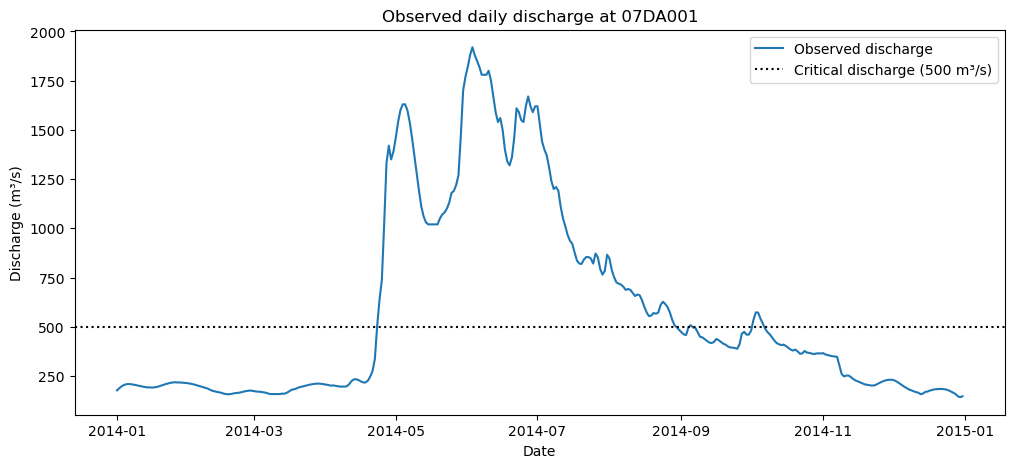

In [24]:
# Plot q_obs

plt.figure(figsize=(12, 5))
plt.plot(q_obs["Date"], q_obs["discharge_m3s"], label="Observed discharge")

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Observed daily discharge at 07DA001")

plt.axhline(
    y=q_critical,
    linestyle=":",
    label=f"Critical discharge ({q_critical} m³/s)",
    color='black'
)

plt.legend()
plt.show()

# Finding range

## Start of range (freshet)

### Idea 1: Rate of change

gemiddelde dQ over 5 dagen periode moet groter zijn dan 15 m^3/s increase per dag voor consecutive dagen 
& Q > Q_kritisch

In [25]:
# # Define dQ

# dQ = Q_today - Q_yesterday

# dQ over 5 dagen periode moet groter zijn dan x m^3/s increase per dag voor consecutive dagen 
# & Q > q_kritisch



### Idea 2: Q_critical 

In [26]:
# Create pd for identified critical dates

freshet_start_date = []

for year, group in q_obs.groupby(q_obs["Date"].dt.year):

    # Set start date to March 1
    start_date_algorithm = pd.to_datetime(f"{year}-03-01")
    season_data = group[group["Date"] >= start_date_algorithm].copy()
    
    # Identify first day where q > q_critical
    
    above_critical = season_data[
        season_data["discharge_m3s"] > q_critical
    ]
    
    if len(above_critical) > 0:
        first_day = above_critical.iloc[0]
        
        freshet_start_date.append({
            "year": year,
            "first_above_critical_date": first_day["Date"],
            "discharge_m3s": first_day["discharge_m3s"]
        })
    else:
        freshet_start_date.append({
            "year": year,
            "first_above_critical_date": pd.NaT,
            "discharge_m3s": None
        })

freshet_start_date = pd.DataFrame(freshet_start_date)

freshet_start_date

,year,first_above_critical_date,discharge_m3s
0,2014,2014-04-23,506.0


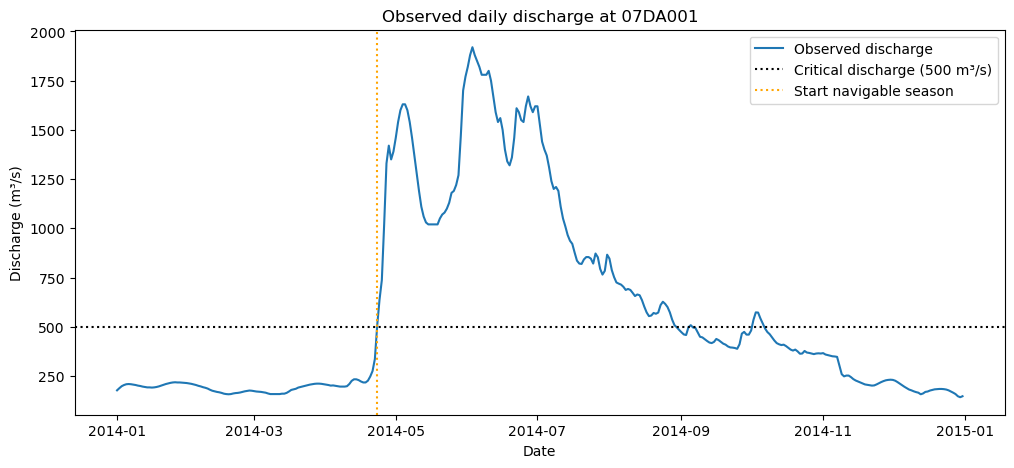

In [27]:
# Plot q_obs

plt.figure(figsize=(12, 5))
plt.plot(q_obs["Date"], q_obs["discharge_m3s"], label='Observed discharge')

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Observed daily discharge at 07DA001")

plt.axhline(
    y=q_critical,
    linestyle=":",
    label=f"Critical discharge ({q_critical} m³/s)",
    color='black'
    )

for date in freshet_start_date["first_above_critical_date"].dropna():
    plt.axvline(
        x=date,
        linestyle=':',
        color='orange',
        label='Start navigable season'
    )
        
plt.legend()
plt.show()

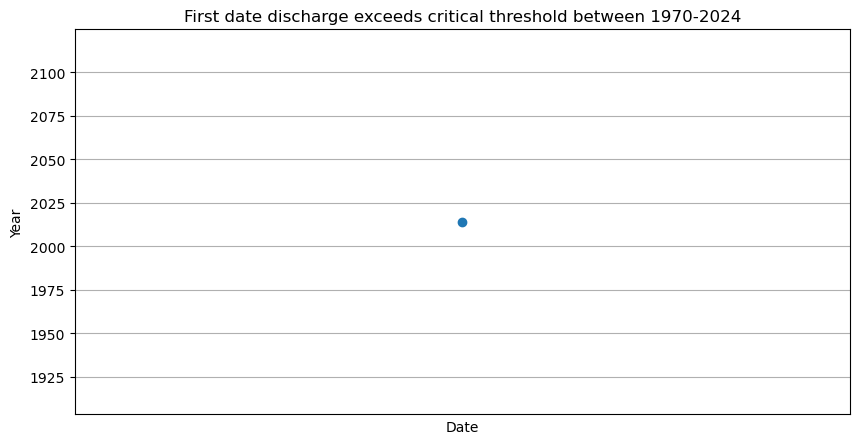

In [28]:
# Convert date to day of year
freshet_start_date["day_of_year"] = (freshet_start_date["first_above_critical_date"].dt.dayofyear)

# Make plot 
plt.figure(figsize=(10, 5))
plt.scatter(freshet_start_date["day_of_year"], freshet_start_date["year"], marker="o")

plt.xlabel("Date")
plt.ylabel("Year")
plt.title("First date discharge exceeds critical threshold between 1970-2024")
plt.grid(True)

# Convert day of year to day in months (on the axis)
plt.xticks(
    [60, 65, 70, 75, 80, 85, 90,
     95, 100, 105, 110, 115, 120,
     125, 130, 135, 140, 145, 150],
    ["Mar 1", "Mar 6", "Mar 11", "Mar 16", "Mar 21", "Mar 26", "Mar 31",
     "Apr 5", "Apr 10", "Apr 15", "Apr 20", "Apr 25", "Apr 30",
     "May 5", "May 10", "May 15", "May 20", "May 25", "May 30"],
)

# Automate x-axis range to fit data
plt.xlim((freshet_start_date["day_of_year"].min()-1), (freshet_start_date["day_of_year"].max()+1))

plt.show()

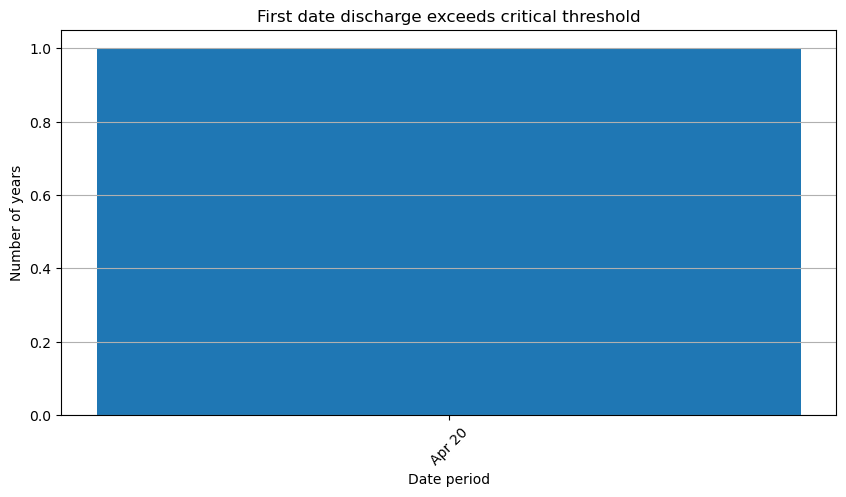

In [29]:
# Creating bar graph

# Choose bin size
bin_size = 5   # use 10 for 10-day periods

# Convert date to day of year
freshet_start_date["day_of_year"] = freshet_start_date["first_above_critical_date"].dt.dayofyear

# Create bins
freshet_start_date["date_bin"] = (freshet_start_date["day_of_year"] // bin_size) * bin_size

# Count how many years fall in each bin
freshet_counts = freshet_start_date.groupby("date_bin").size()

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(freshet_counts.index, freshet_counts.values, width=bin_size)

# Convert x-axis from day-of-year to calendar dates
tick_days = freshet_counts.index
tick_labels = [
    (pd.to_datetime("2001-01-01") + pd.to_timedelta(day - 1, unit="D")).strftime("%b %d")
    for day in tick_days
]

plt.xticks(tick_days, tick_labels, rotation=45)

plt.xlabel("Date period")
plt.ylabel("Number of years")
plt.title("First date discharge exceeds critical threshold")
plt.grid(axis="y")

plt.show()

## End of range (river freeze-up)

### Idea 1: Critical when AFDD = x

AFDD is Accumulated Freeze Degree Days. It calculates the accumulative temperature under 0. 
Example: If 3 days have a mean temperature of -5 C per day, the AFDD would be 15. 

A study shows the LAR forms an ice sheet when AFDD reaches (approx) 50 degrees. https://www.iahr.org/library/infor?pid=26767 (Figure 6)

### Load ERA5-forcings & TAS data

In [30]:
# Generate ERA5 data

# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
#     directory=forcing_path_ERA5
# )

# Load ERA5 data

# load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script" 
# ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

In [31]:
# Exract tas file from Era5
tas_file = Path(ERA5_forcing.directory) / ERA5_forcing.filenames["tas"]

# Extract tas data from tas file
temp_data = xr.open_dataset(tas_file)["tas"]

# Convert to panda
temp_data = temp_data.to_series()
temp_data.index = pd.to_datetime(temp_data.index).tz_localize(None).normalize()

# Convert Kelvin to Celsius:
temp_data = temp_data - 273.15

# Create dataframe with Date, Temp & year as columns
temp_data = pd.DataFrame({
    "Date": temp_data.index,
    "Temp": temp_data.values,
    "year": temp_data.index.year
})

In [32]:
AFDD_critical = 30
AFDD_critical_dates = []

# min_subzero_days = 5
# consec_days = 7

start_year = start_date.year
end_year = end_date.year

for year in range(start_year, end_year + 1):

    # Set start date to 1 August
    year_data = temp_data[
        (temp_data["year"] == year) &
        (temp_data["Date"] >= pd.to_datetime(f"{year}-10-01"))
    ]

    AFDD = 0
    
    # Isolate datasets of date & temperature data to each year 
    for i in range(len(year_data)):
        temp = year_data.iloc[i]["Temp"]
        date = year_data.iloc[i]["Date"]

        # Cumulative AFDD
        if temp < 0:
            AFDD += -temp

        # Append when AFDD is critical
        if AFDD >= AFDD_critical:
            AFDD_critical_dates.append({
                "year": year,
                "AFDD_critical_date": date,
                "AFDD": AFDD,
                "Temp": temp
            })

            break 

AFDD_critical_dates = pd.DataFrame(AFDD_critical_dates)

print(AFDD_critical_dates)

        # # Criteria 1: 5 of 7 consecutive days must be sub-zero
        # if i >= consec_days - 1:
        #     last_7_days = year_data.iloc[i - consec_days + 1 : i + 1]
        #     subzero_days = 0

        #     for j in range(len(last_7_days)):
        #         if last_7_days.iloc[j]["Temp"] < 0:
        #             subzero_days += 1

        #      if AFDD >= AFDD_critical and subzero_days >= required_subzero_days:
        #         AFDD_critical_dates.append({
        #             "year": year,
        #             "AFDD_critical_date": date,
        #             "AFDD": AFDD,
        #             "Subzero days in 7 day period": subzero_days
        #     })
        #     break

AFDD_critical_dates

year AFDD_critical_date       AFDD       Temp
0  2014         2014-11-10  41.426453 -13.859253

,year,AFDD_critical_date,AFDD,Temp
0,2014,2014-11-10,41.426453,-13.859253


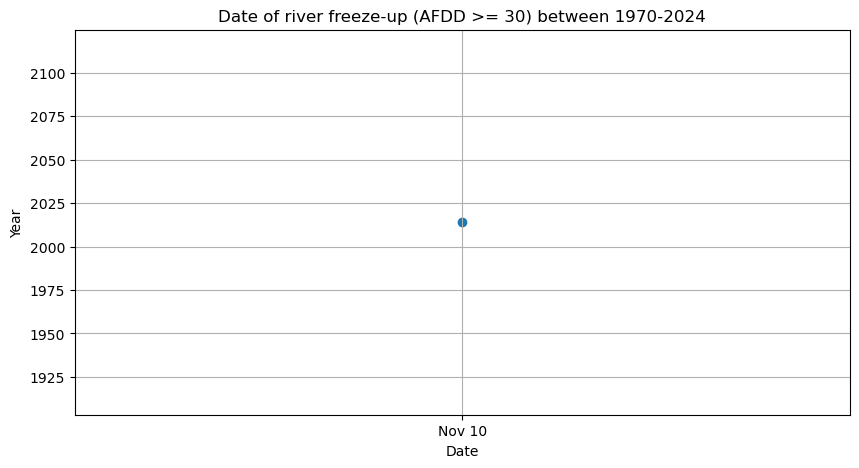

In [33]:
# Convert date to day of year
AFDD_critical_dates["day_of_year"] = (AFDD_critical_dates["AFDD_critical_date"].dt.dayofyear)

# Make plot 
plt.figure(figsize=(10, 5))
plt.scatter(AFDD_critical_dates["day_of_year"], AFDD_critical_dates["year"], marker="o")

plt.xlabel("Date")
plt.ylabel("Year")
plt.title(f"Date of river freeze-up (AFDD >= {AFDD_critical}) between 1970-2024")
plt.grid(True)

# Convert day of year to day in months (on the axis)
plt.xticks(
    [274, 279, 284, 289, 294, 299, 304,
     309, 314, 319, 324, 329, 334, 339,
     344, 349, 354, 359, 364, 366],
    ["Oct 1", "Oct 6", "Oct 11", "Oct 16", "Oct 21", "Oct 26", "Oct 31",
     "Nov 5", "Nov 10", "Nov 15", "Nov 20", "Nov 25", "Nov 30", "Dec 5",
     "Dec 10", "Dec 15", "Dec 20", "Dec 25", "Dec 30", "Dec 31"],
)

# Prevent y-axis from showing decimal years
# plt.yticks(range(start_year, end_year + 1))

# Automate x-axis range to fit data
plt.xlim((AFDD_critical_dates["day_of_year"].min()-1), (AFDD_critical_dates["day_of_year"].max()+1))

plt.show()

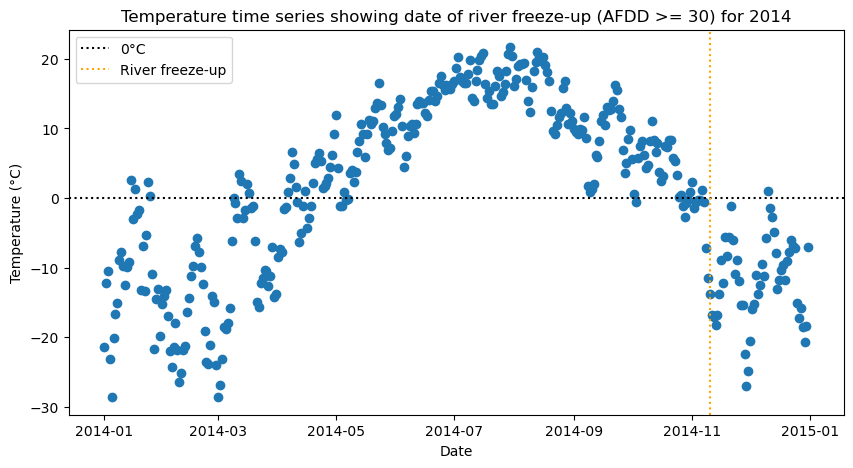

In [34]:
# Plot temp for 1 year for fun:
selected_year = 2014
year_data = temp_data[temp_data["year"] == selected_year]

plt.figure(figsize=(10, 5))
plt.title(f"Temperature time series showing date of river freeze-up (AFDD >= {AFDD_critical}) for 2014")
plt.scatter(year_data["Date"], year_data["Temp"], marker="o")
plt.axhline(
    y=0,
    linestyle=":",
    color="black",
    label="0°C"
)

# Extract & plot critical AFDD date for selected year
AFDD_critical_date = AFDD_critical_dates.loc[AFDD_critical_dates["year"] == selected_year, "AFDD_critical_date"].iloc[0]
plt.axvline(
    x=AFDD_critical_date,
    linestyle=":",
    color="orange",
    label="River freeze-up"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

### Idea 2: Critical when q_critical < 500